In [2]:
import numpy as np
from numpy import random
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

I0000 00:00:1777778692.991910  486682 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777778692.995355  486682 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777778693.398178  486682 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777778696.748872  486682 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

## Q1: Data Generation: Sine Curves

Generate **10,000 sine curves** of the form:

$$
x(t) = A \cdot \sin(\omega t + \phi)
$$

where the parameters are drawn from uniform distributions:

- Amplitude: $ A \sim \mathcal{U}[0.5, 1.5] $
- Frequency: $ \omega \sim \mathcal{U}[0.5, 2] $
- Phase: $ \phi \sim \mathcal{U}[0, 2\pi] $

Sample each curve at $N = 100$ equally spaced points over $t \in [0, 4\pi]$.
Your clean_curve array should have shape (10000, 100).

In [3]:
# generate dataset
clean_curve = np.zeros((10000, 100))
t_arr = np.linspace(0, 4 * np.pi, 100)
for i in range(0, 10000):
    amp = np.random.uniform(0.5, 1.5)
    omega = np.random.uniform(0.5, 2)
    phi = np.random.uniform(0, 2 * np.pi)
    clean_curve[i] = amp * np.sin((omega * t_arr) + phi)

## Add Gaussian Noise

$$
x_{\text{noisy}}(t) = x(t) + \epsilon, \qquad \epsilon \sim \mathcal{N}(0, \sigma^2), \quad \sigma = 0.2
$$
Your noisy_curve array should have shape (10000, 100).

In [4]:
# generate noisy data
noisy_curve = np.zeros((10000, 100))
for i in range(0, 10000):
    epsilon = np.random.normal(loc = 0, scale = 0.2, size = 100)
    noisy_curve[i] = clean_curve[i] + epsilon

Plot examples showing the clean and noisy curve.

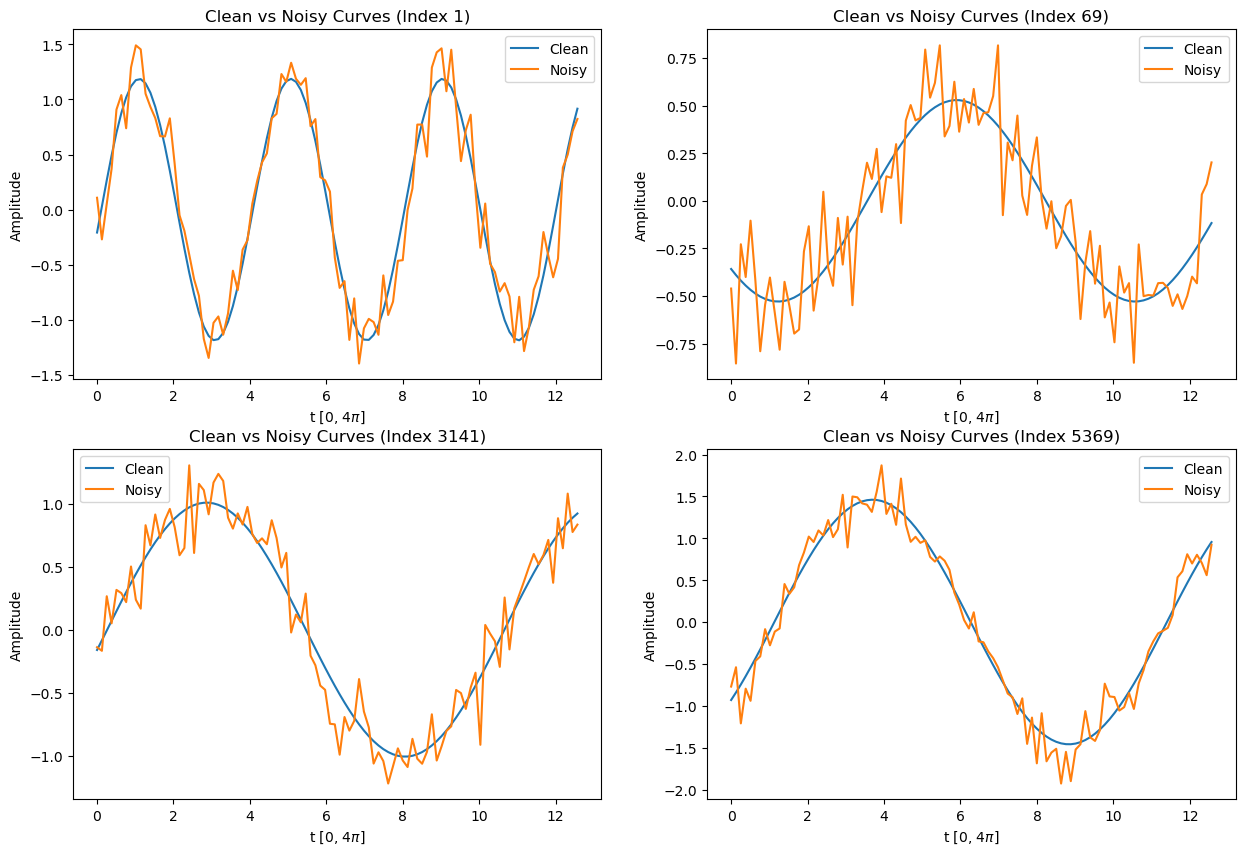

In [5]:
# plot clean vs noisy examples
fig, ax = plt.subplots(2, 2, figsize = (15, 10))

ax[0][0].plot(t_arr, clean_curve[1], label = "Clean")
ax[0][0].plot(t_arr, noisy_curve[1], label = "Noisy")
ax[0][0].set_xlabel("t [0, 4$\pi$]")
ax[0][0].set_ylabel("Amplitude")
ax[0][0].set_title("Clean vs Noisy Curves (Index 1)")
ax[0][0].legend()

ax[0][1].plot(t_arr, clean_curve[69], label = "Clean")
ax[0][1].plot(t_arr, noisy_curve[69], label = "Noisy")
ax[0][1].set_xlabel("t [0, 4$\pi$]")
ax[0][1].set_ylabel("Amplitude")
ax[0][1].set_title("Clean vs Noisy Curves (Index 69)")
ax[0][1].legend()

ax[1][0].plot(t_arr, clean_curve[3141], label = "Clean")
ax[1][0].plot(t_arr, noisy_curve[3141], label = "Noisy")
ax[1][0].set_xlabel("t [0, 4$\pi$]")
ax[1][0].set_ylabel("Amplitude")
ax[1][0].set_title("Clean vs Noisy Curves (Index 3141)")
ax[1][0].legend()

ax[1][1].plot(t_arr, clean_curve[5369], label = "Clean")
ax[1][1].plot(t_arr, noisy_curve[5369], label = "Noisy")
ax[1][1].set_xlabel("t [0, 4$\pi$]")
ax[1][1].set_ylabel("Amplitude")
ax[1][1].set_title("Clean vs Noisy Curves (Index 5369)")
ax[1][1].legend()

## Dataset Split

Split into **90% training / 10% validation**.
- **Input**  (noisy_curve) : X_train -> shape (9000, 100), X_val -> shape (1000, 100)
- **Target** (clean_curve): Y_train -> shape (9000, 100), Y_val -> shape (1000, 100)

In [6]:
# dataset split
X_train = noisy_curve[0:9000]
X_val = noisy_curve[9000:]
Y_train = clean_curve[0:9000]
Y_val = clean_curve[9000:]

## Q2: Autoencoder Model

**Fully connected (dense) autoencoder**
- **Encoder** compresses the input into a low-dimensional **latent space**
- **Decoder** reconstructs the signal from the latent representation

The network is trained to minimise **mean squared error (MSE)** between the reconstructed and clean signal.

In [7]:
N = 100
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

E0000 00:00:1777778723.650081  486682 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1777778723.650489  487036 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1777778723.673072  486682 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,092 (58.95 KB)

 Trainable params: 15,092 (58.95 KB)

 Non-trainable params: 0 (0.00 B)

## Training with .fit()

.fit() trains the model. The key arguments are:

| Argument | What it means |
|---|---|
| X_train, Y_train | The data the model learns from |
| epochs | How many times the model sees the full training data |
| batch_size | How many samples to process before updating the weights |
| validation_data=(X_val, Y_val) | Data the model never trains on. It is used to check performance after each epoch |
| verbose=1 | Shows a progress bar while training; set to 0 to hide it |

After training, history stores the training loss and validation loss at every epoch:

If validation loss starts increasing while training loss keeps decreasing -> the model is **overfitting** (memorising the training data instead of generalising).

In [8]:
history = autoencoder.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_val, Y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3698 - val_loss: 0.1321
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0600 - val_loss: 0.0280
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0211 - val_loss: 0.0179
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0159 - val_loss: 0.0150
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0135 - val_loss: 0.0129
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0118 - val_loss: 0.0113
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0102 - val_loss: 0.0095
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0088 - val_loss: 0.0085
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0080 - val_loss: 0.0077
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0074 - val_loss: 0.0075
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0070 - val_loss: 0.0070
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0066 - val_lo

Plot the training and validation loss curves.

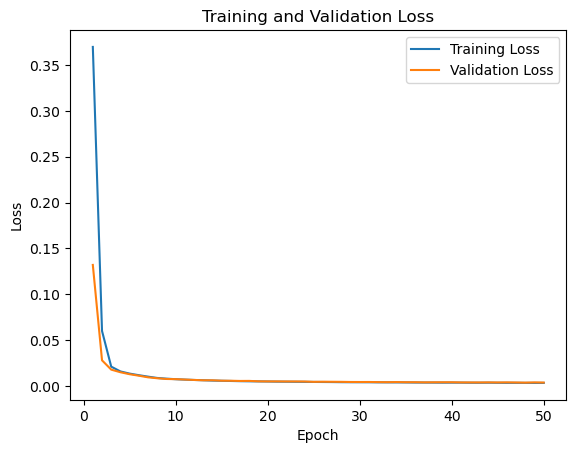

In [9]:
# plot loss curves
plt.plot(epochs_range, train_loss, label = "Training Loss")
plt.plot(epochs_range, val_loss, label = "Validation Loss")
plt.title("Training and Validation Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

## Making Predictions with .predict()

model.predict(X) passes the input array through the trained network and returns reconstructed outputs.

In [18]:
clean_recon_Y = autoencoder.predict(X_train)
noisy_recon_Y = autoencoder.predict(X_val)

282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 909us/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


Plot the clean signal, noisy input, and reconstructed signal.

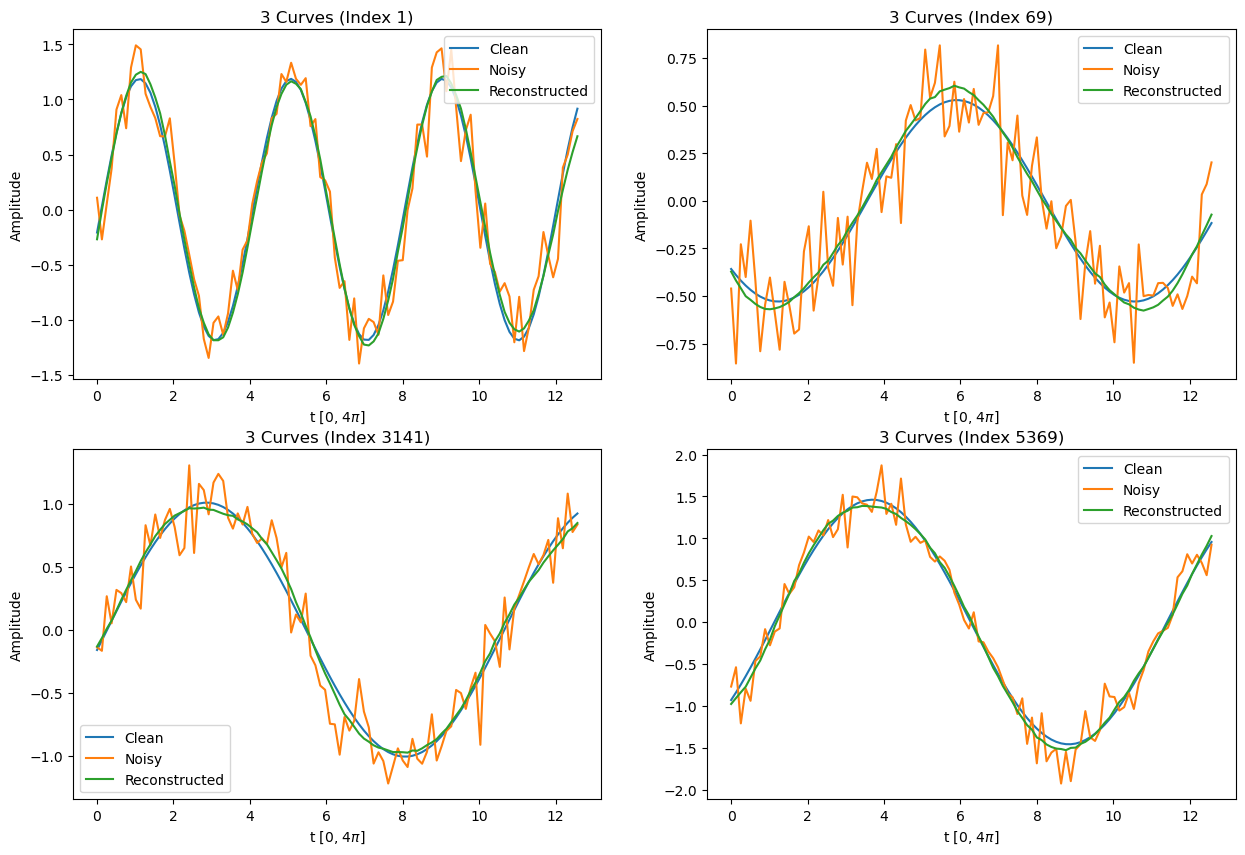

In [20]:
# Plot clean / noisy / reconstructed for each example
fig, ax = plt.subplots(2, 2, figsize = (15, 10))

ax[0][0].plot(t_arr, clean_curve[1], label = "Clean")
ax[0][0].plot(t_arr, noisy_curve[1], label = "Noisy")
ax[0][0].plot(t_arr, clean_recon_Y[1], label = "Reconstructed")
ax[0][0].set_xlabel("t [0, 4$\pi$]")
ax[0][0].set_ylabel("Amplitude")
ax[0][0].set_title("3 Curves (Index 1)")
ax[0][0].legend()

ax[0][1].plot(t_arr, clean_curve[69], label = "Clean")
ax[0][1].plot(t_arr, noisy_curve[69], label = "Noisy")
ax[0][1].plot(t_arr, clean_recon_Y[69], label = "Reconstructed")
ax[0][1].set_xlabel("t [0, 4$\pi$]")
ax[0][1].set_ylabel("Amplitude")
ax[0][1].set_title("3 Curves (Index 69)")
ax[0][1].legend()

ax[1][0].plot(t_arr, clean_curve[3141], label = "Clean")
ax[1][0].plot(t_arr, noisy_curve[3141], label = "Noisy")
ax[1][0].plot(t_arr, clean_recon_Y[3141], label = "Reconstructed")
ax[1][0].set_xlabel("t [0, 4$\pi$]")
ax[1][0].set_ylabel("Amplitude")
ax[1][0].set_title("3 Curves (Index 3141)")
ax[1][0].legend()

ax[1][1].plot(t_arr, clean_curve[5369], label = "Clean")
ax[1][1].plot(t_arr, noisy_curve[5369], label = "Noisy")
ax[1][1].plot(t_arr, clean_recon_Y[5369], label = "Reconstructed")
ax[1][1].set_xlabel("t [0, 4$\pi$]")
ax[1][1].set_ylabel("Amplitude")
ax[1][1].set_title("3 Curves (Index 5369)")
ax[1][1].legend()

## Q3: Parameter Exploration
Investigate how performance changes when modifying the following parameters. For each experiment, provide plots of training and validation loss vs. epochs. Also report the architecture and
comment on whether training converges and whether you observe overfitting.


# A.) Training Data Size
- 90% training , 10% validation (baseline)
- 60% training , 40% validation
- 30% training , 70% validation

Discuss the effect on validation MSE and overfitting.


In [21]:
# Generate data set and add Gaussian Noise just like before
clean_data = np.zeros((10000, 100))
t_arr = np.linspace(0, 4 * np.pi, 100)
for i in range(0, 10000):
    amp = np.random.uniform(0.5, 1.5)
    omega = np.random.uniform(0.5, 2)
    phi = np.random.uniform(0, 2 * np.pi)
    clean_curve[i] = amp * np.sin((omega * t_arr) + phi)

noisy_data = np.zeros((10000, 100))
for i in range(0, 10000):
    epsilon = np.random.normal(loc = 0, scale = 0.2, size = 100)
    noisy_data[i] = clean_data[i] + epsilon

In [23]:
# Split data into various training and validation arrays
# 90 - 10 BASELINE
X_train_90 = noisy_data[0:9000]
X_val_10 = noisy_data[9000:]
Y_train_90 = clean_data[0:9000]
Y_val_10 = clean_data[9000:]

# 60 - 40 DATA
X_train_60 = noisy_data[0:6000]
X_val_40 = noisy_data[6000:]
Y_train_60 = clean_data[0:6000]
Y_val_40 = clean_data[6000:]

# 30 - 70 DATA
X_train_30 = noisy_data[0:3000]
X_val_70 = noisy_data[3000:]
Y_train_30 = clean_data[0:3000]
Y_val_70 = clean_data[3000:]

In [24]:
# Run autoencoder for 90/10, 60/40, and 30/70
history_9010 = autoencoder.fit(
    X_train_90, Y_train_90,
    epochs=50,
    batch_size=128,
    validation_data=(X_val_10, Y_val_10),
    verbose=0
)

history_6040 = autoencoder.fit(
    X_train_60, Y_train_60,
    epochs=50,
    batch_size=128,
    validation_data=(X_val_40, Y_val_40),
    verbose=0
)

history_3070 = autoencoder.fit(
    X_train_30, Y_train_30,
    epochs=50,
    batch_size=128,
    validation_data=(X_val_70, Y_val_70),
    verbose=0
)

# Extract loss values for 90/10, 60/40, and 30/70
train_loss_9010   = history_9010.history['loss']
val_loss_9010     = history_9010.history['val_loss']
epochs_range_9010 = range(1, len(train_loss_9010) + 1)

train_loss_6040   = history_6040.history['loss']
val_loss_6040     = history_6040.history['val_loss']
epochs_range_6040 = range(1, len(train_loss_6040) + 1)

train_loss_3070   = history_3070.history['loss']
val_loss_3070     = history_3070.history['val_loss']
epochs_range_3070 = range(1, len(train_loss_3070) + 1)

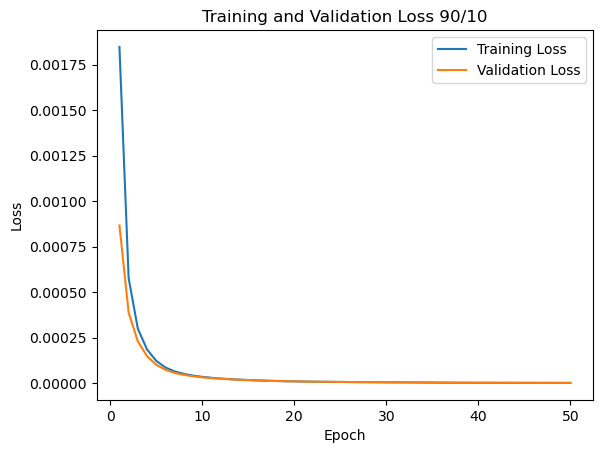

In [25]:
# Plot loss curves for 90/10, 60/40, and 30/70
plt.plot(epochs_range_9010, train_loss_9010, label = "Training Loss")
plt.plot(epochs_range_9010, val_loss_9010, label = "Validation Loss")
plt.title("Training and Validation Loss 90/10")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

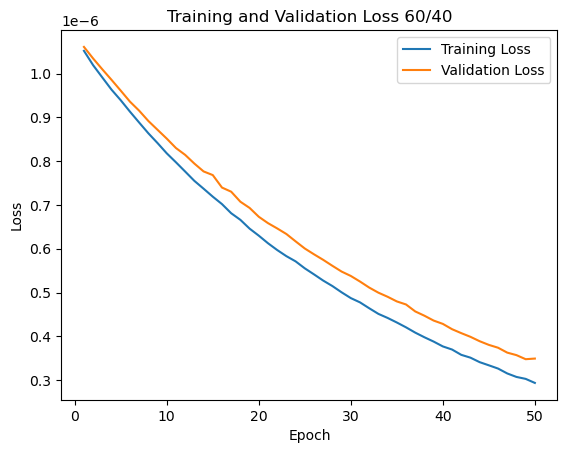

In [26]:
plt.plot(epochs_range_6040, train_loss_6040, label = "Training Loss")
plt.plot(epochs_range_6040, val_loss_6040, label = "Validation Loss")
plt.title("Training and Validation Loss 60/40")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

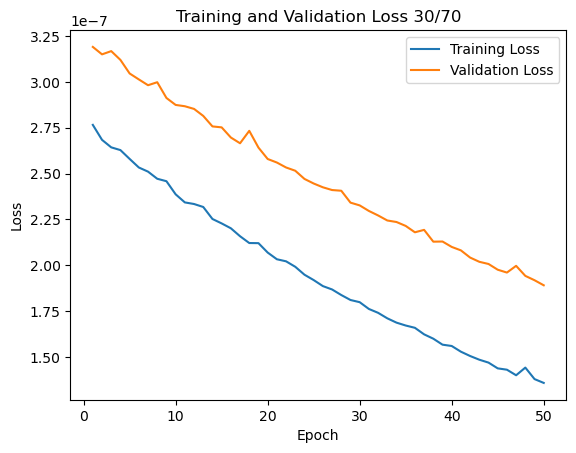

In [27]:
plt.plot(epochs_range_3070, train_loss_3070, label = "Training Loss")
plt.plot(epochs_range_3070, val_loss_3070, label = "Validation Loss")
plt.title("Training and Validation Loss 30/70")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

# B.) Network Architecture

Fix the bottleneck at 4 and experiment with different numbers of layers and neurons.
For example:
- Model 1 (Baseline): 100 → 64 → 4 → 64 → 100
- Model 2 : 100 → 80 → 40 → 4 → 40 → 80 → 100
- Model 3 : 100 → 64 → 32 → 16 → 4 → 16 → 32 → 64 → 100

Record the training time and final validation MSE for each architecture.


In [28]:
# Declare 3 model autoencoders
N = 100

autoencoder_1 = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
]) # 100 -> 64 -> 4 -> 64 -> 100
autoencoder_1.compile(optimizer=Adam(0.001), loss='mse')
autoencoder_1.summary()

autoencoder_2 = Sequential([
    Input(shape=(N,)),
    Dense(80, activation='relu'),
    Dense(40, activation='relu'),
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(40, activation='relu'),
    Dense(80, activation='relu'),
    Dense(N,  activation='linear') # output layer
]) # 100 -> 80 -> 40 -> 4 -> 40 -> 80 -> 100
autoencoder_2.compile(optimizer=Adam(0.001), loss='mse')
autoencoder_2.summary()

autoencoder_3 = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(16, activation='relu'),
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
]) # 100 -> 64 -> 32 -> 16 -> 4 -> 16 -> 32 -> 64 -> 100
autoencoder_3.compile(optimizer=Adam(0.001), loss='mse')
autoencoder_3.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,544 (52.91 KB)

 Trainable params: 13,544 (52.91 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,376 (71.78 KB)

 Trainable params: 18,376 (71.78 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Test with original data from Q1 and Q2
history_1 = autoencoder_1.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_val, Y_val),
    verbose=0
)

history_2 = autoencoder_2.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_val, Y_val),
    verbose=0
)

history_3 = autoencoder_3.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_val, Y_val),
    verbose=0
)

# extract loss values for plotting
train_loss_1   = history_1.history['loss'] # training loss per epoch
val_loss_1     = history_1.history['val_loss'] # validation loss per epoch
epochs_range_1 = range(1, len(train_loss_1) + 1)

train_loss_2   = history_2.history['loss'] # training loss per epoch
val_loss_2     = history_2.history['val_loss'] # validation loss per epoch
epochs_range_2 = range(1, len(train_loss_2) + 1)

train_loss_3   = history_3.history['loss'] # training loss per epoch
val_loss_3     = history_3.history['val_loss'] # validation loss per epoch
epochs_range_3 = range(1, len(train_loss_3) + 1)

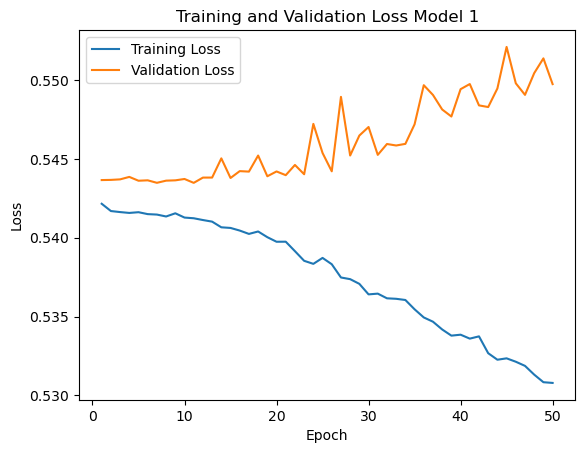

In [30]:
plt.plot(epochs_range_1, train_loss_1, label = "Training Loss")
plt.plot(epochs_range_1, val_loss_1, label = "Validation Loss")
plt.title("Training and Validation Loss Model 1")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

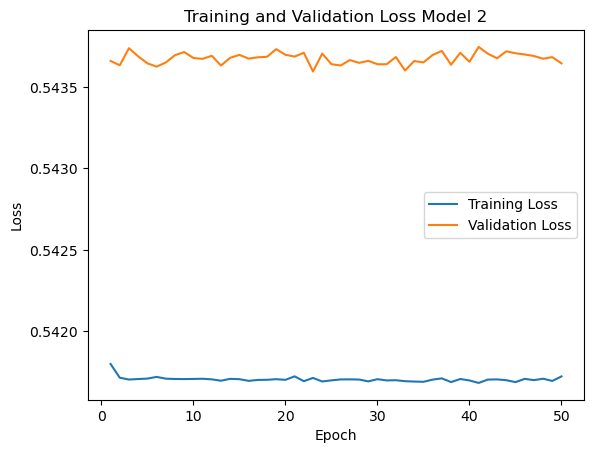

In [31]:
plt.plot(epochs_range_2, train_loss_2, label = "Training Loss")
plt.plot(epochs_range_2, val_loss_2, label = "Validation Loss")
plt.title("Training and Validation Loss Model 2")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

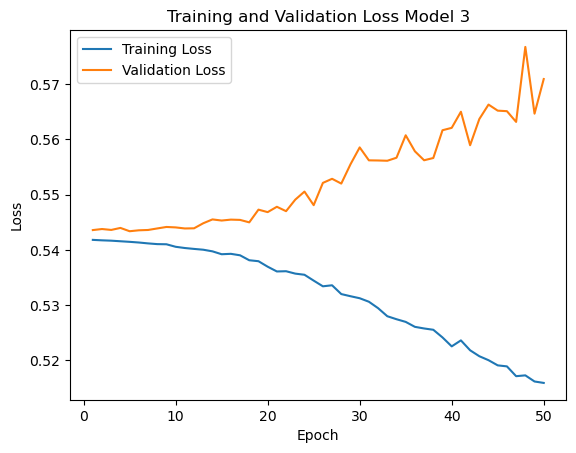

In [33]:
plt.plot(epochs_range_3, train_loss_3, label = "Training Loss")
plt.plot(epochs_range_3, val_loss_3, label = "Validation Loss")
plt.title("Training and Validation Loss Model 3")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

# C.) Bottleneck Size

Fix the outer architecture (N → 64 → · → 64 → N) and vary the bottleneck dimension:
16, 8, 4, 3, 2, 1. Determine the smallest bottleneck size that still reconstructs the signal accurately.


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_86 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,092 (58.95 KB)

 Trainable params: 15,092 (58.95 KB)

 Non-trainable params: 0 (0.00 B)

282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


TypeError: 'Axes' object is not subscriptable

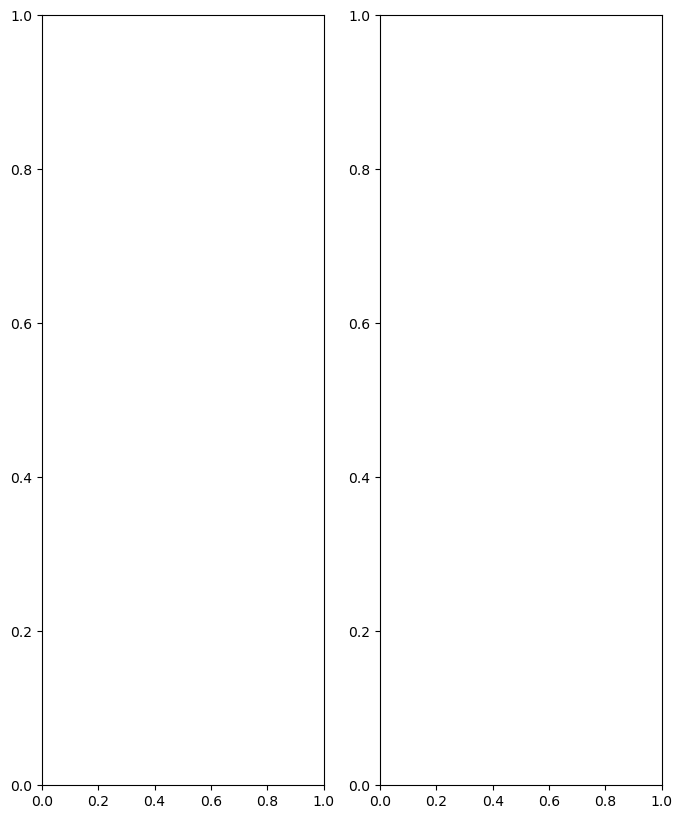

In [39]:
N = 100
bottleneck = [16, 8, 4, 3, 2, 1]

for x in bottleneck:
    auto_bottle = Sequential([
        Input(shape=(N,)),
        Dense(64, activation='relu'),
        Dense(x, activation='relu'),  # latent (bottleneck) layer
        Dense(64, activation='relu'),
        Dense(N,  activation='linear') # output layer
    ]) # 100 -> 64 -> 4 -> 64 -> 100
    auto_bottle.compile(optimizer=Adam(0.001), loss='mse')
    auto_bottle.summary()

    hist = auto_bottle.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_val, Y_val),
    verbose=0
    )

    train_bottle_loss   = hist.history['loss'] # training loss per epoch
    val_bottle_loss     = hist.history['val_loss'] # validation loss per epoch
    epochs = range(1, len(train_bottle_loss) + 1)

    clean_reconstruct = auto_bottle.predict(X_train)
    noisy_reconstruct = auto_bottle.predict(X_val)

    fig, ax = plt.subplots(1, 2, figsize = (8, 10))
    ax[0][0].plot(epochs, train_bottle_loss, label = "Training Loss")
    ax[0][0].plot(epochs, val_bottle_loss, label = "Validation Loss")
    ax[0][0].set_xlabel("Epoch")
    ax[0][0].set_ylabel("Loss")
    ax[0][0].set_title(f"Training and Validation Bottleneck {x}")
    ax[0][0].legend()
    ax[0][0].imshow()

    ax[0][1].plot(t_arr, clean_curve[69], label = "Clean")
    ax[0][1].plot(t_arr, noisy_curve[69], label = "Noisy")
    ax[0][1].plot(t_arr, clean_reconstruct[69], label = "Reconstructed")
    ax[0][1].set_xlabel("t [0, 4$\pi$]")
    ax[0][1].set_ylabel("Amplitude")
    ax[0][1].set_title("3 Curves (Index 69)")
    ax[0][1].legend()
    ax[0][1].imshow()

# D.) Noise Models

Instead of Gaussian, test Laplacian noise

In [43]:
clean_laplace = np.zeros((10000, 100))
t_arr = np.linspace(0, 4 * np.pi, 100)
for i in range(0, 10000):
    amp = np.random.uniform(0.5, 1.5)
    omega = np.random.uniform(0.5, 2)
    phi = np.random.uniform(0, 2 * np.pi)
    clean_laplace[i] = amp * np.sin((omega * t_arr) + phi)

noisy_laplace = np.zeros((10000, 100))
for i in range(0, 10000):
    epsilon = np.random.laplace(loc = 0, scale = 0.2, size = 100)
    noisy_laplace[i] = clean_laplace[i] + epsilon

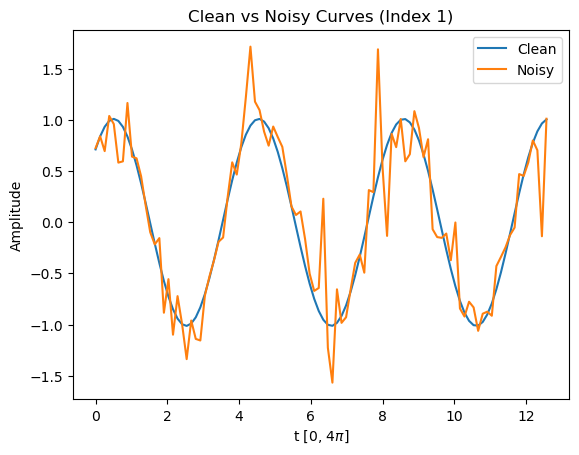

In [45]:
plt.plot(t_arr, clean_laplace[1], label = "Clean")
plt.plot(t_arr, noisy_laplace[1], label = "Noisy")
plt.xlabel("t [0, 4$\pi$]")
plt.ylabel("Amplitude")
plt.title("Clean vs Noisy Curves (Index 1)")
plt.legend()

In [46]:
# dataset split
X_train_lap = noisy_laplace[0:9000]
X_val_lap = noisy_laplace[9000:]
Y_train_lap = clean_laplace[0:9000]
Y_val_lap = clean_laplace[9000:]

In [47]:
N = 100
auto_laplace = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

auto_laplace.compile(optimizer=Adam(0.001), loss='mse')
auto_laplace.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_90 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_91 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_92 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_93 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,092 (58.95 KB)

 Trainable params: 15,092 (58.95 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
history_lap = auto_laplace.fit(
    X_train_lap, Y_train_lap,
    epochs=50,
    batch_size=128,
    validation_data=(X_val_lap, Y_val_lap),
    verbose=1
)

# extract loss values for plotting
train_loss_lap   = history_lap.history['loss'] # training loss per epoch
val_loss_lap     = history_lap.history['val_loss'] # validation loss per epoch
epochs_range_lap = range(1, len(train_loss_lap) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3849 - val_loss: 0.1437
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0697 - val_loss: 0.0413
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0290 - val_loss: 0.0245
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0207 - val_loss: 0.0206
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0175 - val_loss: 0.0177
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0155 - val_loss: 0.0156
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0138 - val_loss: 0.0138
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0124 - val_loss: 0.0129
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0116 - val_loss: 0.0119
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0109 - val_loss: 0.0113
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0104 - val_loss: 0.0107
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0099 - val_lo

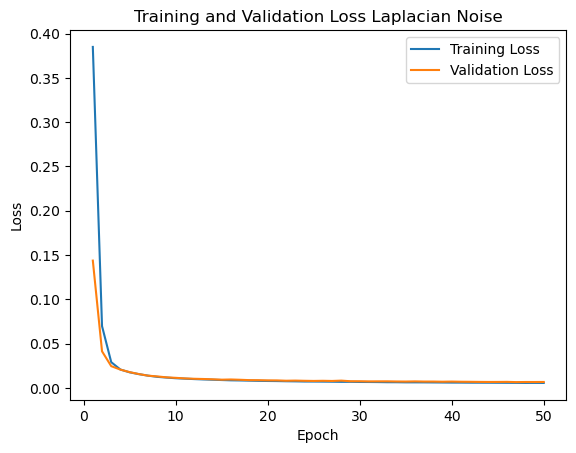

In [49]:
# plot loss curves
plt.plot(epochs_range_lap, train_loss_lap, label = "Training Loss")
plt.plot(epochs_range_lap, val_loss_lap, label = "Validation Loss")
plt.title("Training and Validation Loss Laplacian Noise")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

In [50]:
clean_recon_lap = auto_laplace.predict(X_train_lap)
noisy_recon_lap = auto_laplace.predict(X_val_lap)

282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


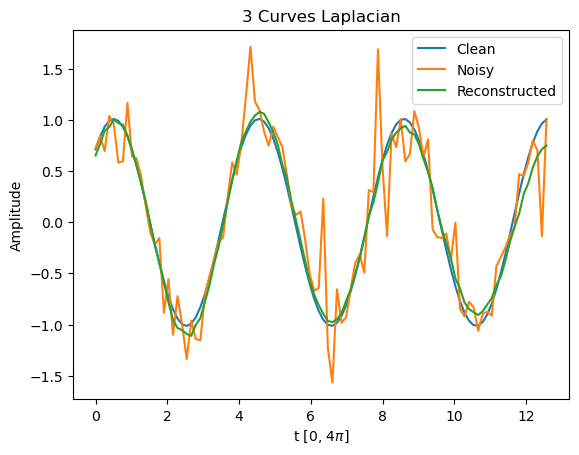

In [51]:
plt.plot(t_arr, clean_laplace[1], label = "Clean")
plt.plot(t_arr, noisy_laplace[1], label = "Noisy")
plt.plot(t_arr, clean_recon_lap[1], label = "Reconstructed")
plt.xlabel("t [0, 4$\pi$]")
plt.ylabel("Amplitude")
plt.title("3 Curves Laplacian")
plt.legend()